In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
import pandas as pd

df = pd.read_csv("../dataset/bank_marketing.csv.csv", sep=';')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print(df.columns)

Dataset Loaded Successfully
Shape: (45211, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [8]:
total_customers = len(df)
converted = len(df[df['y'] == 'yes'])
not_converted = len(df[df['y'] == 'no'])

conversion_rate = (converted / total_customers) * 100

print("Total Customers:", total_customers)
print("Converted Customers:", converted)
print("Not Converted:", not_converted)
print("Conversion Rate:", round(conversion_rate, 2), "%")

Total Customers: 45211
Converted Customers: 5289
Not Converted: 39922
Conversion Rate: 11.7 %


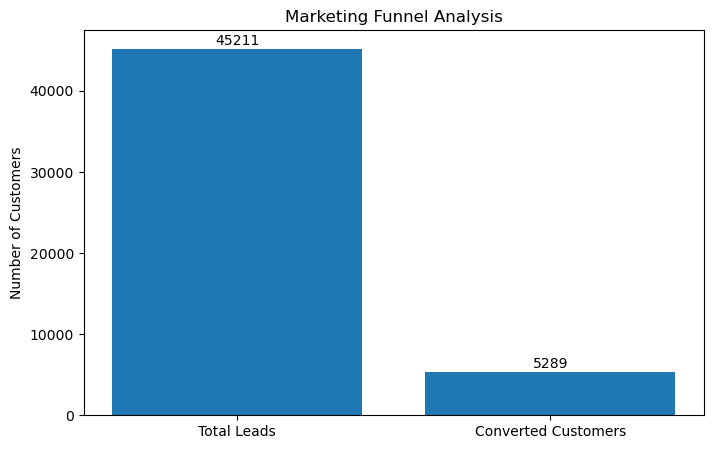

In [9]:
import matplotlib.pyplot as plt

funnel_data = [45211, 5289]
stages = ['Total Leads', 'Converted Customers']

plt.figure(figsize=(8,5))
plt.bar(stages, funnel_data)
plt.title("Marketing Funnel Analysis")
plt.ylabel("Number of Customers")

for i, value in enumerate(funnel_data):
    plt.text(i, value + 500, str(value), ha='center')

plt.show()

In [10]:
contact_performance = pd.crosstab(df['contact'], df['y'])

print(contact_performance)

y             no   yes
contact               
cellular   24916  4369
telephone   2516   390
unknown    12490   530


In [11]:
contact_conversion = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

print(contact_conversion)

y                 no        yes
contact                        
cellular   85.081100  14.918900
telephone  86.579491  13.420509
unknown    95.929339   4.070661


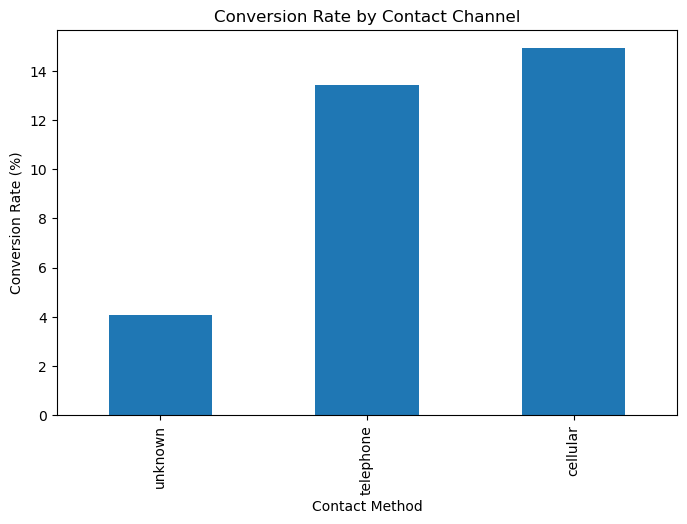

In [12]:
contact_conversion['yes'].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Conversion Rate by Contact Channel")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Contact Method")
plt.show()

In [13]:
job_conversion = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_conversion = job_conversion.sort_values(
    by='yes',
    ascending=False
)

print(job_conversion)

y                     no        yes
job                                
student        71.321962  28.678038
retired        77.208481  22.791519
unemployed     84.497314  15.502686
management     86.244449  13.755551
admin.         87.797331  12.202669
self-employed  88.157061  11.842939
unknown        88.194444  11.805556
technician     88.943004  11.056996
services       91.116996   8.883004
housemaid      91.209677   8.790323
entrepreneur   91.728312   8.271688
blue-collar    92.725031   7.274969


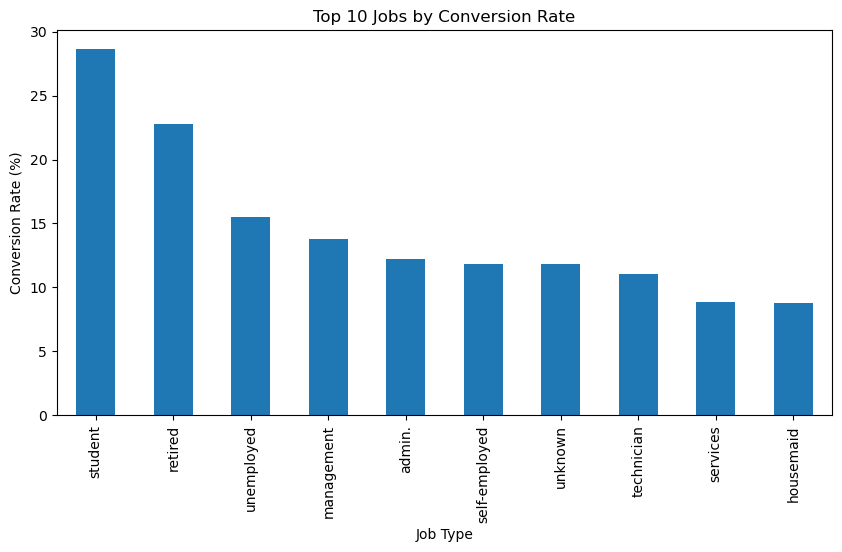

In [14]:
job_conversion['yes'].head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Jobs by Conversion Rate")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Job Type")
plt.show()

In [15]:
month_conversion = pd.crosstab(
    df['month'],
    df['y'],
    normalize='index'
) * 100

print(month_conversion)

y             no        yes
month                      
apr    80.320600  19.679400
aug    88.986714  11.013286
dec    53.271028  46.728972
feb    83.352208  16.647792
jan    89.878831  10.121169
jul    90.906454   9.093546
jun    89.777195  10.222805
mar    48.008386  51.991614
may    93.280546   6.719454
nov    89.848866  10.151134
oct    56.233062  43.766938
sep    53.540587  46.459413


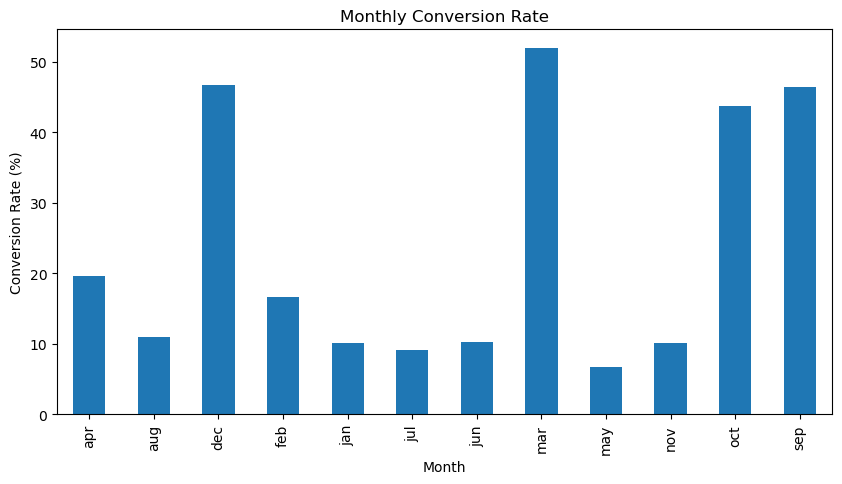

In [16]:
month_conversion['yes'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Monthly Conversion Rate")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Month")
plt.show()

In [17]:
education_conversion = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_conversion = education_conversion.sort_values(
    by='yes',
    ascending=False
)

print(education_conversion)

y                 no        yes
education                      
tertiary   84.993610  15.006390
unknown    86.429725  13.570275
secondary  89.440565  10.559435
primary    91.373522   8.626478


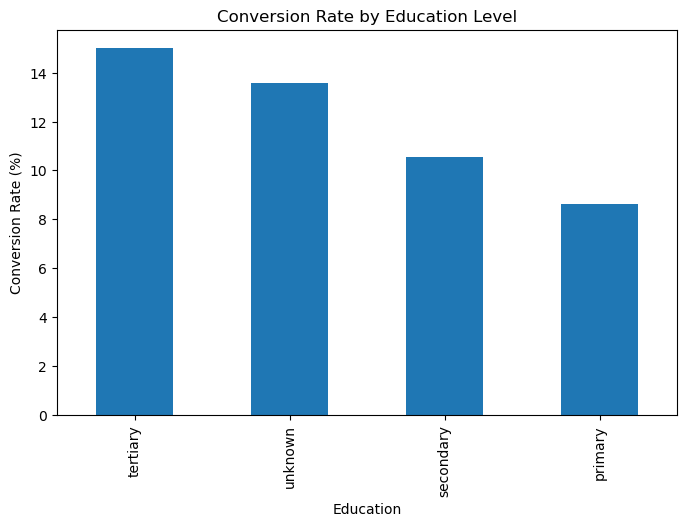

In [18]:
education_conversion['yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Conversion Rate by Education Level")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Education")
plt.show()

In [19]:
housing_conversion = pd.crosstab(
    df['housing'],
    df['y'],
    normalize='index'
) * 100

print(housing_conversion)

y               no        yes
housing                      
no       83.297645  16.702355
yes      92.300040   7.699960


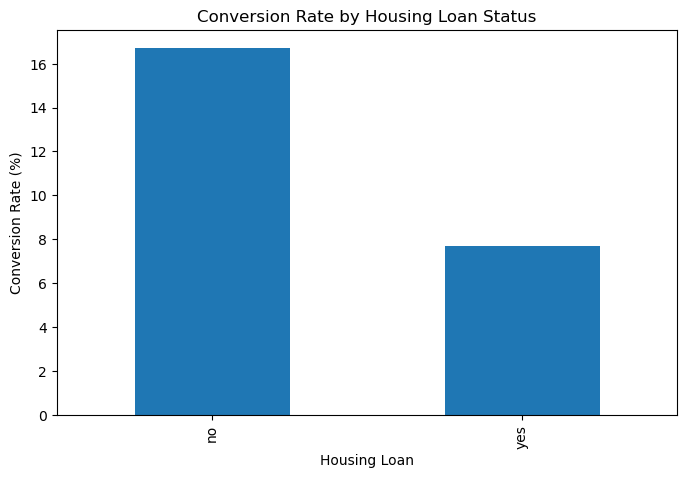

In [20]:
housing_conversion['yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Conversion Rate by Housing Loan Status")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Housing Loan")
plt.show()

## Key Insights

1. Overall conversion rate is 11.7%.
2. Majority of leads do not convert, indicating significant funnel drop-off.
3. Cellular contact channel shows better conversion performance.
4. Certain job categories convert at higher rates than others.
5. Conversion rates vary significantly across months.
6. Education level influences customer conversion behavior.
7. Housing loan status impacts conversion likelihood.

## Recommendations

- Increase investment in high-performing contact channels.
- Target customer segments with higher conversion rates.
- Focus campaigns during high-converting months.
- Personalize marketing for different education and job groups.
- Optimize follow-up strategies to reduce funnel drop-offs.